# Road lanes and vehicle detection

The pipeline isolates plausible white/yellow road markings, detects Hough segments, clusters boundaries, and rejects lines inconsistent with the dominant vanishing point. Paint occupancy distinguishes solid/dashed markings. Adjacent boundaries define visible lane regions.

A pretrained MobileNet-SSD detects cars/buses in the full frame and overlapping crops. The bottom-center of each box determines its lane. Bounding-box height is an uncalibrated closeness proxy. A temporal tracker smooths boundary positions and requires persistent side changes before emitting a possible crossing cue. Roadside camera views have no ego-lane interpretation.

Saved results cover all eight still images and 90 video frames. Vehicle misses, guardrail false positives and curved-line errors remain; there is no labeled precision/recall benchmark.

In [1]:
from pathlib import Path
import sys, json, os
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'cvprojects').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
DATA = Path(os.environ.get('CV_DATA_ROOT', str(ROOT / 'data')))
RUN_PIPELINE = False  # set True after downloading the data


In [2]:
from cvprojects.lanes import run_images, run_video
if RUN_PIPELINE:
    run_images(DATA / 'roads', ROOT / 'results/project2', DATA / 'weights')
    run_video(DATA / 'video1.mp4', ROOT / 'results/project2/video1', DATA / 'weights', 90)
results = json.loads((ROOT / 'results/project2/detections.json').read_text())
display(pd.DataFrame([{'image': name, 'boundaries': len(r['boundaries']), 'vehicles': len(r['vehicles']), 'ego_lane': r['ego_lane_id']} for name,r in results.items()]))

,image,boundaries,vehicles,ego_lane
0,road1.png,4,0,2.0
1,road1b.png,4,0,2.0
2,road2.jpg,6,0,NaN
3,road2b.jpg,5,0,NaN
4,road3.jpg,2,1,1.0
5,road3b.jpg,3,0,1.0
6,road4.png,6,1,NaN
7,road4b.png,6,1,NaN


Processed frames: 90
Possible crossing cues: 0
These are unverified detector outputs, not ground-truth crossing counts.


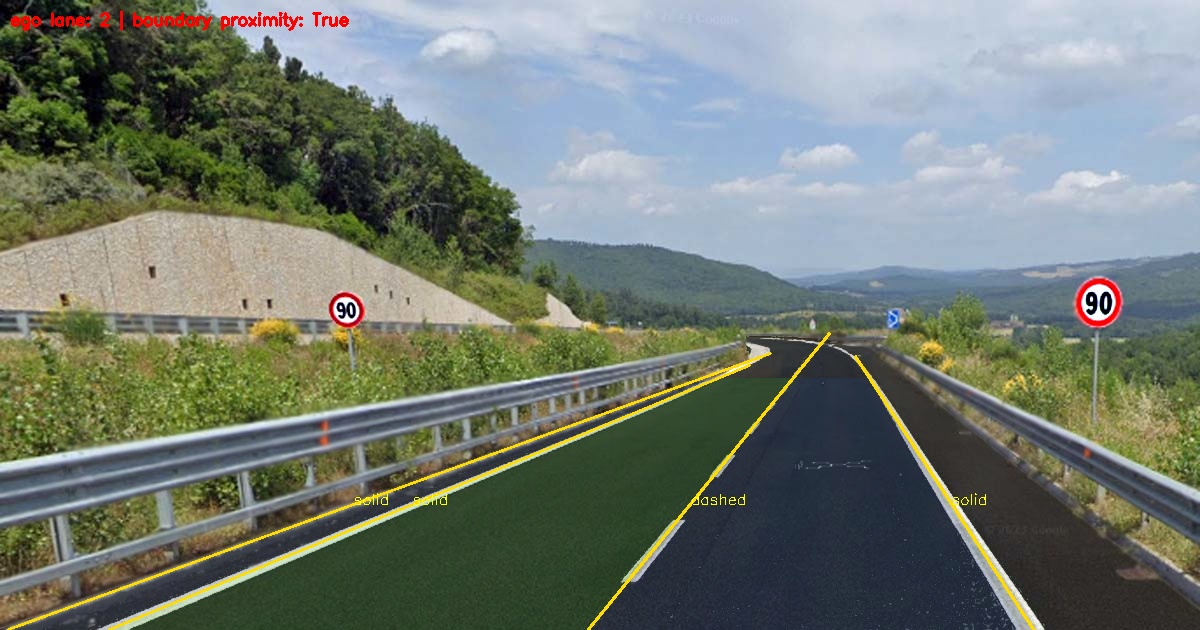

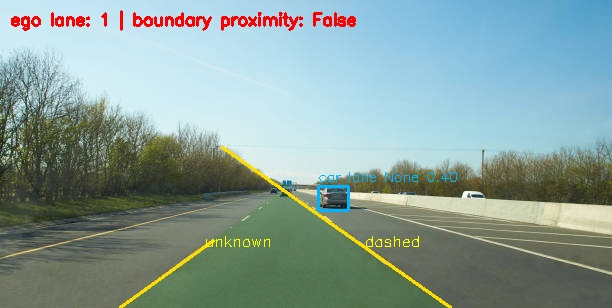

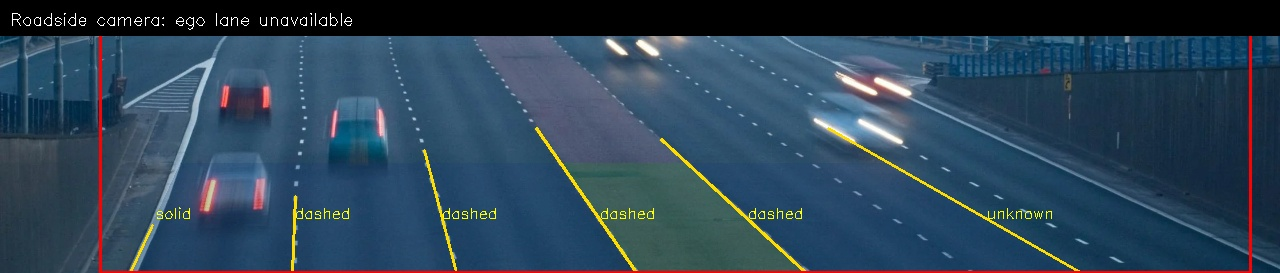

In [3]:
for name in ['road1_annotated.jpg', 'road3_annotated.jpg', 'road4_annotated.jpg']:
    display(Image(filename=str(ROOT / 'results/project2' / name), width=850))
frames = json.loads((ROOT / 'results/project2/video1/frames.json').read_text())
print('Processed frames:', len(frames))
print('Possible crossing cues:', sum(r['possible_crossing'] for r in frames))
print('These are unverified detector outputs, not ground-truth crossing counts.')

## Interpretation and reproduction

See `../docs/RESULTS.md` for the observed results and limitations, and `../README.md` for download/run commands. The saved outputs shown above come from the included experiment. Set `RUN_PIPELINE = True` to regenerate them using local datasets.